# **LAB3: Regression Analysis**




---
* Created By: Rakshitha V S | 2348448

* Created Date: 29.02.2024

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Aim: The aim of this non-parametric Data Exploration project is to analyze and gain valuable insights into the factors influencing the salaries of engineering graduates

## 1) Constructing a dataset (Data Collection)

#### Data Collection: The dataset is collected from Kaggle which is Engineering Graduate Salary Prediction. The different featured columns of this dataset are:
#### ID: A unique ID to identify a candidate
#### Salary: Annual CTC offered to the candidate (in INR)
#### Gender: Candidate's gender
#### DOB: Date of birth of the candidate
#### 10percentage: Overall marks obtained in grade 10 examinations
#### 10board: The school board whose curriculum the candidate followed in grade 10
#### 12graduation: Year of graduation - senior year high school
#### 12percentage: Overall marks obtained in grade 12 examinations
#### 12board: The school board whose curriculum the candidate followed
#### CollegeID: Unique ID identifying the university/college which the candidate attended for her/his undergraduate
#### CollegeTier: Each college has been annotated as 1 or 2. The annotations have been computed from the average AMCAT scores obtained by the students in the college/university. Colleges with an average score above a threshold are tagged as 1 and others as 2.
#### Degree: Degree obtained/pursued by the candidate
#### Specialization: Specialization pursued by the candidate
#### CollegeGPA: Aggregate GPA at graduation
#### CollegeCityID: A unique ID to identify the city in which the college is located in.
#### CollegeCityTier: The tier of the city in which the college is located in. This is annotated based on the population of the cities.
#### CollegeState: Name of the state in which the college is located
#### GraduationYear: Year of graduation (Bachelor's degree)
#### English: Scores in AMCAT English section
#### Logical: Score in AMCAT Logical ability section
#### Quant: Score in AMCAT's Quantitative ability section
#### Domain: Scores in AMCAT's domain module
#### ComputerProgramming: Score in AMCAT's Computer programming section
#### ElectronicsAndSemicon: Score in AMCAT's Electronics & Semiconductor Engineering section
#### ComputerScience: Score in AMCAT's Computer Science section
#### MechanicalEngg: Score in AMCAT's Mechanical Engineering section
#### ElectricalEngg: Score in AMCAT's Electrical Engineering section
#### TelecomEngg: Score in AMCAT's Telecommunication Engineering section
#### CivilEngg: Score in AMCAT's Civil Engineering section
#### conscientiousness: Scores in one of the sections of AMCAT's personality test
#### agreeableness: Scores in one of the sections of AMCAT's personality test
#### extraversion: Scores in one of the sections of AMCAT's personality test
#### nueroticism: Scores in one of the sections of AMCAT's personality test
#### openess_to_experience: Scores in one of the sections of AMCAT's personality test

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn import metrics
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/TRISEM 3-ML/Engineering_graduate_salary.csv")
data

,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,...,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,...,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,...,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,...,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993,103174,f,1989-04-17,75.00,0,2005,73.00,0,1263,2,...,-1,-1,-1,-1,-1.1901,0.9688,-1.0697,1.35490,0.0284,120000
2994,352811,f,1991-07-22,84.00,state board,2008,77.00,state board,9481,2,...,-1,-1,-1,-1,-0.1082,0.0328,-0.4891,-0.29020,0.5024,120000
2995,287070,m,1988-11-24,91.40,bsemp,2006,65.56,bsemp,547,2,...,-1,-1,-1,-1,-0.8810,0.1888,-0.3440,0.06230,0.6603,385000
2996,317336,m,1988-08-25,88.64,karnataka education board,2006,65.16,karnataka education board,1629,2,...,-1,-1,-1,-1,1.4374,1.2808,-0.4891,-1.46537,0.5419,530000


## 2) Displaying basic information about the dataset like the number of samples, features, data types, etc.

In [ ]:
#Basic information about the dataset like the number of samples, features, data types, etc.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2998 entries, 0 to 2997
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2998 non-null   int64  
 1   Gender                 2998 non-null   object 
 2   DOB                    2998 non-null   object 
 3   10percentage           2998 non-null   float64
 4   10board                2998 non-null   object 
 5   12graduation           2998 non-null   int64  
 6   12percentage           2998 non-null   float64
 7   12board                2998 non-null   object 
 8   CollegeID              2998 non-null   int64  
 9   CollegeTier            2998 non-null   int64  
 10  Degree                 2998 non-null   object 
 11  Specialization         2998 non-null   object 
 12  collegeGPA             2998 non-null   float64
 13  CollegeCityID          2998 non-null   int64  
 14  CollegeCityTier        2998 non-null   int64  
 15  Coll

In [ ]:
data.isna().sum()

ID                       0
Gender                   0
DOB                      0
10percentage             0
10board                  0
12graduation             0
12percentage             0
12board                  0
CollegeID                0
CollegeTier              0
Degree                   0
Specialization           0
collegeGPA               0
CollegeCityID            0
CollegeCityTier          0
CollegeState             0
GraduationYear           0
English                  0
Logical                  0
Quant                    0
Domain                   0
ComputerProgramming      0
ElectronicsAndSemicon    0
ComputerScience          0
MechanicalEngg           0
ElectricalEngg           0
TelecomEngg              0
CivilEngg                0
conscientiousness        0
agreeableness            0
extraversion             0
nueroticism              0
openess_to_experience    0
Salary                   0
dtype: int64

In [ ]:
#For numerical variables:
#Basic descriptive statistics
data.describe()

,ID,10percentage,12graduation,12percentage,CollegeID,CollegeTier,collegeGPA,CollegeCityID,CollegeCityTier,GraduationYear,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
count,2.998000e+03,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,...,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2998.000000,2.998000e+03
mean,6.648926e+05,77.666264,2008.080720,74.341061,5210.210807,1.924616,71.509857,5210.210807,0.296197,2011.939960,...,24.138759,16.267845,31.068379,1.946965,-0.038714,0.126217,-0.008662,-0.145965,-0.141111,3.051748e+05
std,3.648951e+05,10.002785,1.631814,11.120299,4776.609877,0.264053,8.122462,4776.609877,0.456655,36.780582,...,99.785138,86.054739,103.552963,32.241501,1.024974,0.955831,0.962695,1.012901,1.007134,2.123312e+05
min,1.124400e+04,43.000000,1998.000000,40.000000,2.000000,1.000000,6.630000,2.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-3.893300,-5.781600,-4.600900,-2.643000,-7.375700,3.500000e+04
25%,3.334648e+05,71.140000,2007.000000,66.000000,526.250000,2.000000,66.530000,526.250000,0.000000,2012.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-0.649100,-0.435300,-0.604800,-0.868200,-0.669200,1.800000e+05
50%,6.396945e+05,78.965000,2008.000000,74.000000,4027.500000,2.000000,71.800000,4027.500000,0.000000,2013.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.046400,0.212400,0.091400,-0.172700,-0.094300,3.000000e+05
75%,9.951770e+05,85.600000,2009.000000,82.600000,8822.250000,2.000000,76.300000,8822.250000,1.000000,2014.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.702700,0.812800,0.672000,0.526200,0.502400,3.700000e+05
max,1.297877e+06,97.760000,2012.000000,98.700000,18409.000000,2.000000,99.930000,18409.000000,1.000000,2017.000000,...,623.000000,660.000000,548.000000,500.000000,1.995300,1.904800,2.161700,3.352500,1.630200,4.000000e+06


In [ ]:
print(data.columns)

Index(['ID', 'Gender', 'DOB', '10percentage', '10board', '12graduation',
       '12percentage', '12board', 'CollegeID', 'CollegeTier', 'Degree',
       'Specialization', 'collegeGPA', 'CollegeCityID', 'CollegeCityTier',
       'CollegeState', 'GraduationYear', 'English', 'Logical', 'Quant',
       'Domain', 'ComputerProgramming', 'ElectronicsAndSemicon',
       'ComputerScience', 'MechanicalEngg', 'ElectricalEngg', 'TelecomEngg',
       'CivilEngg', 'conscientiousness', 'agreeableness', 'extraversion',
       'nueroticism', 'openess_to_experience', 'Salary'],
      dtype='object')


## 3) Displaying the first few rows to understand the structure and format of the data.

In [ ]:
data.head()

,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,...,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,...,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,...,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,...,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000


## 4) Univariate Analysis:

### For numerical variables:
#### a) Calculate basic descriptive statistics (mean, median, mode, standard deviation, min, max, quartiles, etc.).

In [ ]:
Salary = data['Salary']
mean = np.mean(Salary)
mode = np.nan
std_dev = np.std(Salary)
minimum = np.min(Salary)
maximum = np.max(Salary)
q1 = np.percentile(Salary, 25)
q3 = np.percentile(Salary, 75)

print("Descriptive Statistics:")
print(f"Mean: {mean:.2f}")
print(f"Mode: {mode}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Maximum: {maximum:.2f}")
print(f"Minimum: {minimum:.2f}")
print(f"1st Quartile (Q1): {q1:.2f}")
print(f"3rd Quartile (Q3): {q3:.2f}")

Descriptive Statistics:
Mean: 305174.78
Mode: nan
Standard Deviation: 212295.78
Maximum: 4000000.00
Minimum: 35000.00
1st Quartile (Q1): 180000.00
3rd Quartile (Q3): 370000.00


#### b) Visualize the distribution using histograms, kernel density plots, or box plots.

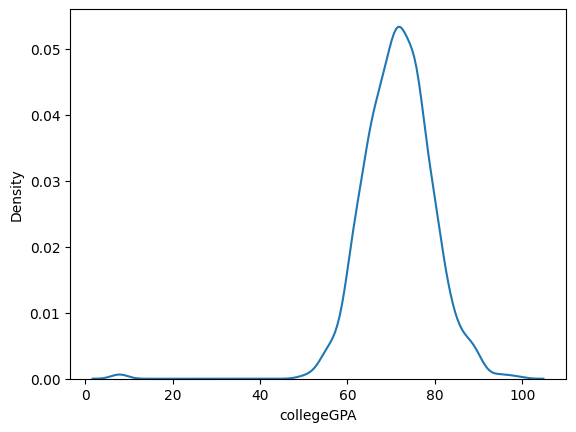

In [ ]:
#kde
sns.kdeplot(data['collegeGPA']);

<Axes: xlabel='collegeGPA', ylabel='Salary'>

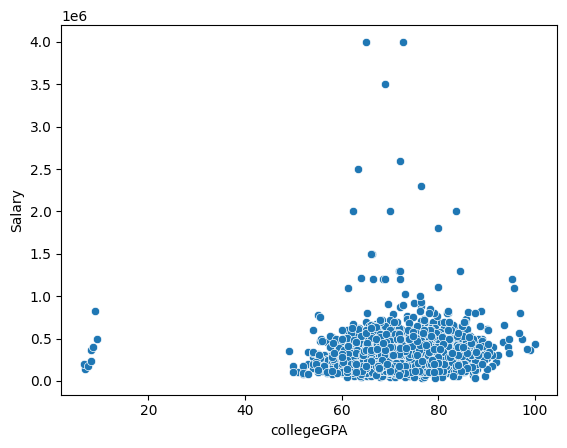

In [ ]:
#scatter plot
sns.scatterplot(x="collegeGPA",y="Salary",data=data)

<Axes: xlabel='Salary'>

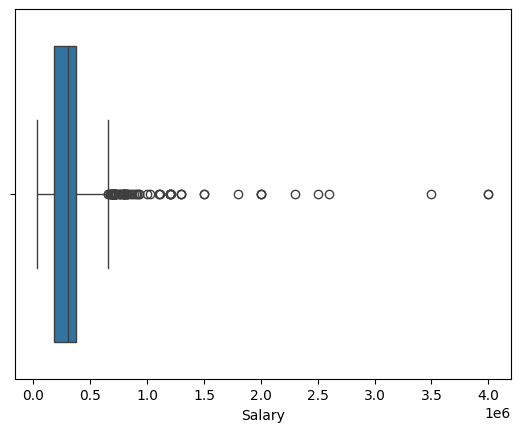

In [ ]:
#box plot
sns.boxplot(x=data.Salary)

### For categorical variables:
#### a) Display frequency tables showing counts and percentages.

<Axes: xlabel='count', ylabel='Specialization'>

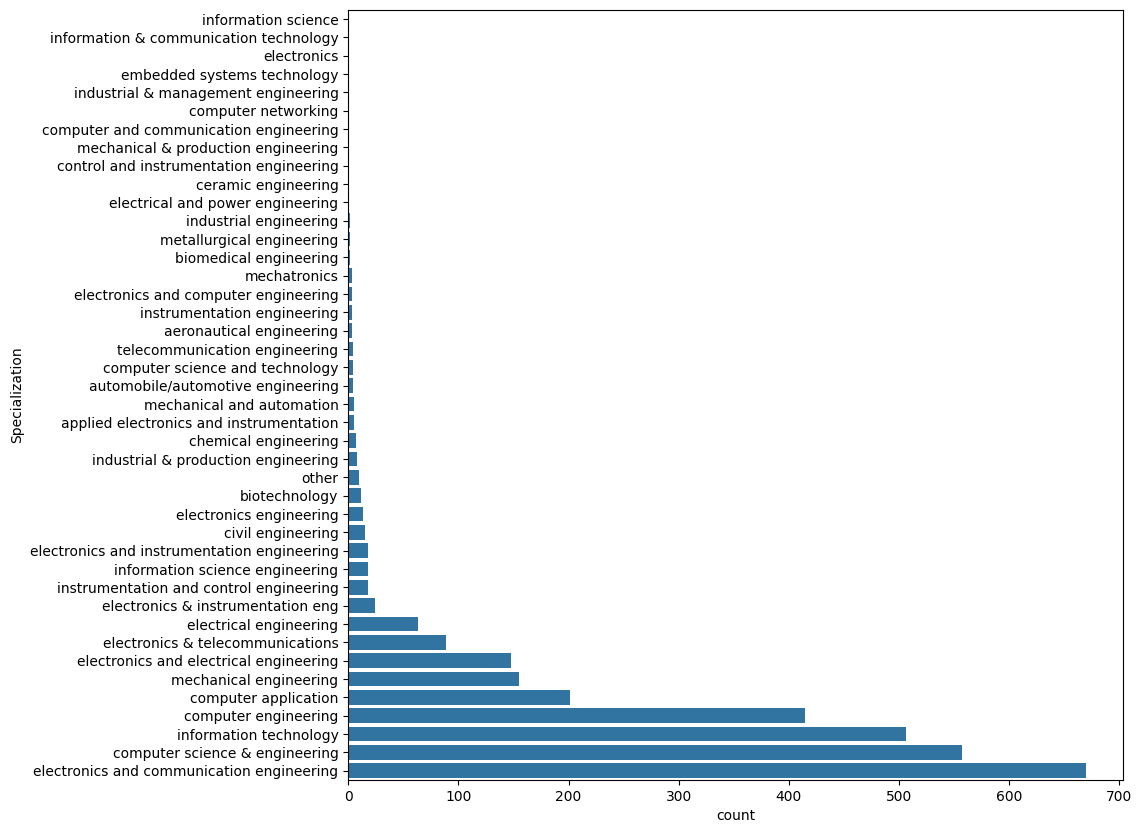

In [ ]:
#count plot
plt.figure(figsize = (10,10))
sns.countplot(y='Specialization',data=data,order=data['Specialization'].value_counts().sort_values().index)

#### b) Visualize using bar plots.

<Axes: xlabel='Degree', ylabel='Salary'>

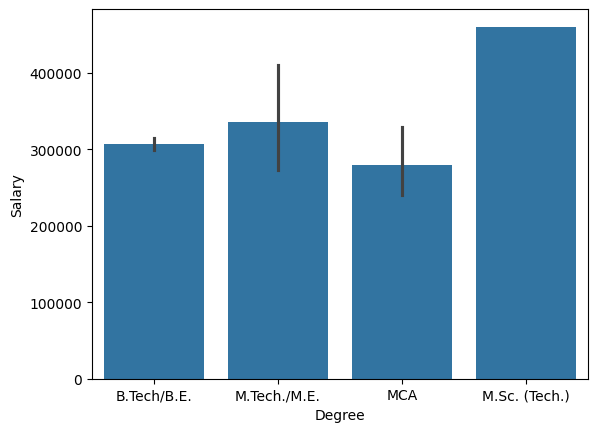

In [ ]:
sns.barplot(x='Degree',y='Salary',data=data)

## 5) Bivariate Analysis:

#### a) Explore relationships between pairs of numerical variables using scatter plots or pair plots.

In [ ]:
columns_to_extract = ['Salary', 'Gender', 'Degree','12percentage','10percentage','Specialization']
data1 = data[columns_to_extract]
data1

,Salary,Gender,Degree,12percentage,10percentage,Specialization
0,445000,f,B.Tech/B.E.,84.00,87.80,instrumentation and control engineering
1,110000,m,B.Tech/B.E.,64.50,57.00,computer science & engineering
2,255000,m,B.Tech/B.E.,85.17,77.33,electronics & telecommunications
3,420000,m,B.Tech/B.E.,86.00,84.30,computer science & engineering
4,200000,f,B.Tech/B.E.,75.00,82.00,biotechnology
...,...,...,...,...,...,...
2993,120000,f,B.Tech/B.E.,73.00,75.00,electronics and communication engineering
2994,120000,f,B.Tech/B.E.,77.00,84.00,information technology
2995,385000,m,B.Tech/B.E.,65.56,91.40,information technology
2996,530000,m,B.Tech/B.E.,65.16,88.64,computer engineering


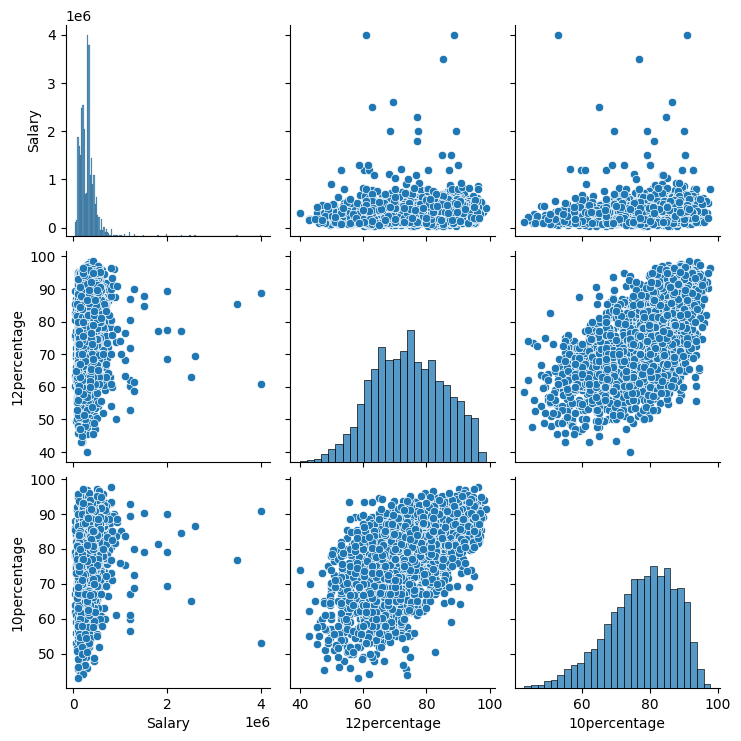

In [ ]:
sns.pairplot(data1)

#### b) Explore relationships between numerical and categorical variables using box plots or violin plots.

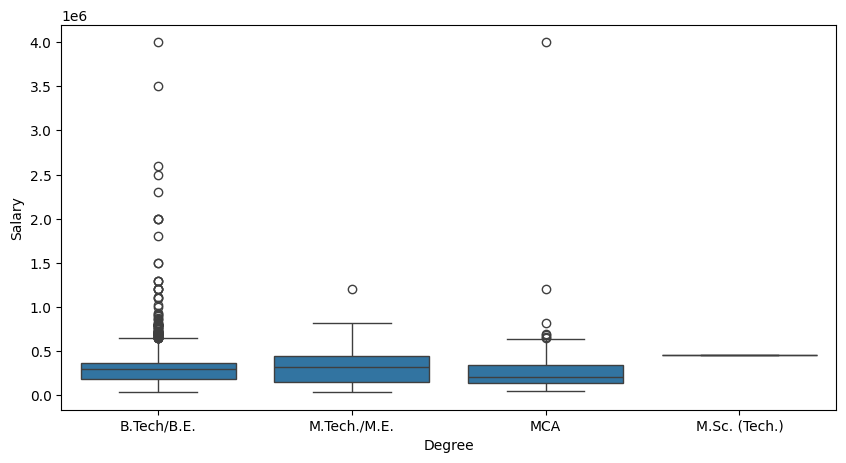

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='Degree', y='Salary')
plt.xlabel('Degree')
plt.ylabel('Salary')
plt.show()

#### c) Calculate correlation coefficients between numerical variables.

In [ ]:
comat=data[['12percentage','Salary','10percentage','collegeGPA']].corr()
print("Correlation Matrix:",comat)

Correlation Matrix:               12percentage    Salary  10percentage  collegeGPA
12percentage      1.000000  0.172755      0.645578    0.335041
Salary            0.172755  1.000000      0.181414    0.131912
10percentage      0.645578  0.181414      1.000000    0.311209
collegeGPA        0.335041  0.131912      0.311209    1.000000


### Data Cleaning

In [ ]:
data["Gender"] = data["Gender"].replace({'m': 0, 'f': 1})

In [ ]:
data.replace(to_replace=-1, value=0,inplace=True)

In [ ]:
data['Total']=data['English']+data['Logical']+data['Quant']+data['Domain']+data['ComputerProgramming']+data['ElectronicsAndSemicon']+data['ComputerScience']+data['MechanicalEngg']+data['ElectricalEngg']+data['TelecomEngg']+data['CivilEngg']+data['conscientiousness']+data['agreeableness']+data['extraversion']+data['nueroticism']

In [ ]:
data = pd.get_dummies(data, columns=["Degree"])

In [ ]:
data = pd.get_dummies(data, columns=["Specialization"])

In [ ]:
columns_to_drop = ['DOB','English', 'Logical', 'Quant', 'Domain', 'ComputerProgramming', 'ElectronicsAndSemicon', 'ComputerScience', 'MechanicalEngg', 'ElectricalEngg', 'TelecomEngg', 'CivilEngg', 'conscientiousness', 'agreeableness', 'extraversion', 'nueroticism','10board','12board','CollegeState']
data = data.drop(columns=columns_to_drop)
data

,ID,Gender,10percentage,12graduation,12percentage,CollegeID,CollegeTier,collegeGPA,CollegeCityID,CollegeCityTier,...,Specialization_information technology,Specialization_instrumentation and control engineering,Specialization_instrumentation engineering,Specialization_mechanical & production engineering,Specialization_mechanical and automation,Specialization_mechanical engineering,Specialization_mechatronics,Specialization_metallurgical engineering,Specialization_other,Specialization_telecommunication engineering
0,604399,1,87.80,2009,84.00,6920,1,73.82,6920,1,...,False,True,False,False,False,False,False,False,False,False
1,988334,0,57.00,2010,64.50,6624,2,65.00,6624,0,...,False,False,False,False,False,False,False,False,False,False
2,301647,0,77.33,2007,85.17,9084,2,61.94,9084,0,...,False,False,False,False,False,False,False,False,False,False
3,582313,0,84.30,2009,86.00,8195,1,80.40,8195,1,...,False,False,False,False,False,False,False,False,False,False
4,339001,1,82.00,2008,75.00,4889,2,64.30,4889,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993,103174,1,75.00,2005,73.00,1263,2,70.00,1263,1,...,False,False,False,False,False,False,False,False,False,False
2994,352811,1,84.00,2008,77.00,9481,2,75.20,9481,0,...,True,False,False,False,False,False,False,False,False,False
2995,287070,0,91.40,2006,65.56,547,2,73.19,547,0,...,True,False,False,False,False,False,False,False,False,False
2996,317336,0,88.64,2006,65.16,1629,2,74.81,1629,1,...,False,False,False,False,False,False,False,False,False,False


## 6) Perform Regression Analysis:

#### (i) Depending on the nature of your data and the relationship between variables, choose an appropriate regression model. Common choices include linear regression (Simple Multiple), polynomial regression, etc.

#### (ii) Train the chosen regression model using the training data.

#### (iii) Evaluate the performance of the trained model using appropriate metrics. For regression, common metrics include Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R-squared, etc.

### Simple Linear Regression

In [ ]:
X = data[['12percentage']]
y = data['Salary']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f'Mean Squared Error: {mse}')
r2=r2_score(y_test,y_pred)
print(f'R^2: {r2}')
mae=metrics.mean_absolute_error(y_test,y_pred)
print(f'Mean absolute error: {mae}')

Mean Squared Error: 176527.56941086202
R^2: 0.056311983485483164
Mean absolute error: 116164.21195206542


R² is the percentage of variation explained by the relationship between two variables.

In [ ]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept: ", model.intercept_)

Slope (Coefficient): 3160.2947745840406
Intercept:  70779.62143840545


In [ ]:
print("The predicted values for",X_test," are:",y_pred)

The predicted values for       12percentage
1449         89.58
215          57.80
349          66.46
2044         89.60
2591         72.00
...            ...
1528         59.00
2795         85.00
2107         60.20
1515         63.80
1318         56.00

[600 rows x 1 columns]  are: [353878.82734564 253444.65940936 280812.81215726 353942.03324114
 298320.84520846 340668.79518788 340036.73623297 281476.47405992
 287575.84297487 348885.5616018  302113.19893796 331187.91086413
 310962.02430679 288302.71077302 293264.37356912 252496.57097699
 267539.57410401 244058.58392885 298794.88942464 270510.25119212
 360578.65226776 368163.35972676 345409.23734976 266717.89746262
 299900.99259575 268614.07432737 364371.00599726 271774.36910195
 323603.20340513 299584.96311829 332135.99929651 269878.1922372
 362474.82913251 302113.19893796 323065.95329345 319810.84967563
 235114.94971678 301481.13998304 358082.01939584 274081.3842874
 314122.31908138 264189.66164295 301165.11050558 283783.48924537
 299

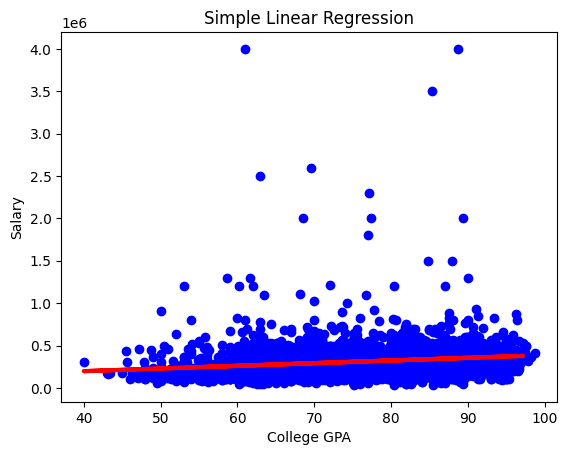

In [ ]:
plt.scatter(X, y, color='blue', label='Actual data')
plt.plot(X_test, y_pred, color='red', linewidth=3,label="Predicted data")
plt.xlabel('College GPA')
plt.ylabel('Salary')
plt.title('Simple Linear Regression')
plt.show()

### Multiple Linear Regression

In [ ]:
X = data[['10percentage']]
y = data['Salary']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f'Mean Squared Error: {mse}')
r2=r2_score(y_test,y_pred)
print(f'R^2: {r2}')
mae=metrics.mean_absolute_error(y_test,y_pred)
print(f'Mean absolute error: {mae}')

Mean Squared Error: 176029.90840055732
R^2: 0.06162531488944578
Mean absolute error: 114393.9310689715


In [ ]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept: ", model.intercept_)

Slope (Coefficient): 3665.434150808179
Intercept:  21053.947098718723


In [ ]:
print("The predicted values for",X_test," are:",y_pred)

The predicted values for       10percentage
1449         90.58
215          73.00
349          71.33
2044         89.00
2591         81.90
...            ...
1528         72.00
2795         77.00
2107         75.20
1515         61.00
1318         46.00

[600 rows x 1 columns]  are: [353068.97247892 288630.64010772 282509.36507587 347277.58652065
 321253.00404991 336281.28406822 328950.41576661 306957.81086176
 334082.02357774 332615.84991741 330416.58942693 348743.76018097
 265428.4419331  277634.33765529 309890.1581824  312529.27077099
 249557.1120601  333825.44318718 253185.8918694  286797.92303231
 339580.17480395 336281.28406822 340533.18768316 226318.25954398
 291306.40703781 272502.72984416 291562.98742836 286431.37961723
 314288.67916337 333348.93674758 357540.80214291 258060.91928998
 332615.84991741 311356.33184273 342255.94173404 338480.54455871
 273968.90350448 292296.07425852 354608.45482226 306444.65008064
 336721.13616632 271036.55618384 325284.9816158  271036.55618384
 3

### Polynomial Regression

In [ ]:
X = data[['collegeGPA']]
y = data['Salary']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

#### for degree 2

In [ ]:
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred = poly_model.predict(X_test_poly)

In [ ]:
mse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f'Mean Squared Error: {mse}')
r2=r2_score(y_test,y_pred)
print(f'R^2: {r2}')
mae=metrics.mean_absolute_error(y_test,y_pred)
print(f'Mean absolute error: {mae}')

Mean Squared Error: 177368.9292373615
R^2: 0.04729499750587007
Mean absolute error: 118245.68392115153


In [ ]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept: ", model.intercept_)

Slope (Coefficient): -0.1245390868927709
Intercept:  23149396.896442473


In [ ]:
print("The predicted values for",X_test," are:",y_pred)

The predicted values for       collegeGPA
1449       72.03
215        58.00
349        60.00
2044       73.33
2591       71.90
...          ...
1528       68.00
2795       68.00
2107       69.54
1515       67.00
1318       75.00

[600 rows x 1 columns]  are: [304421.83918034 260813.95094729 265820.54438757 309464.55383564
 303926.91513205 317430.1174322  331603.16249305 279077.16795971
 311130.0622617  362343.28853815 296887.34734846 306921.95237792
 309978.1727184  293679.5257914  308168.38485856 277795.17013452
 261661.06696475 342204.89694554 283253.85901221 268963.11256154
 286511.38520229 354531.25469025 331334.94286239 271229.39354516
 280096.89675146 315986.40590402 303926.91513205 280096.89675146
 280003.74159635 283671.65052672 317803.34870524 286511.38520229
 288379.52619306 330310.12141855 383619.63550306 307388.15779101
 277040.49842004 283093.62250585 353293.87611501 296887.34734846
 327223.83319196 288514.17160241 291586.23185489 283253.85901221
 349765.34274244 320354.49

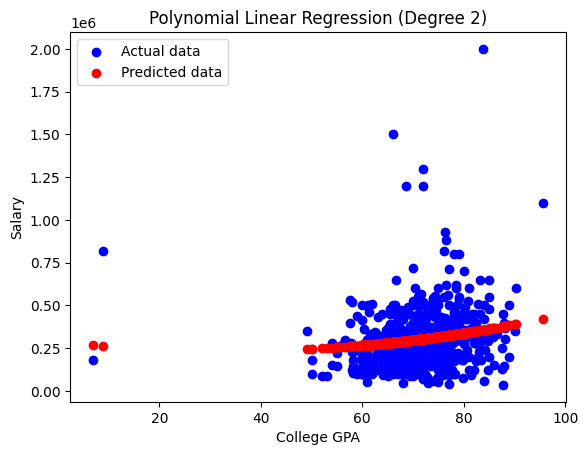

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual data')
plt.scatter(X_test, y_pred, color='red', label='Predicted data')
plt.xlabel('College GPA')
plt.ylabel('Salary')
plt.title(f'Polynomial Linear Regression (Degree {degree})')
plt.legend()
plt.show()

#### for degree 2

In [ ]:
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred = poly_model.predict(X_test_poly)

In [ ]:
mse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f'Mean Squared Error: {mse}')
r2=r2_score(y_test,y_pred)
print(f'R^2: {r2}')
mae=metrics.mean_absolute_error(y_test,y_pred)
print(f'Mean absolute error: {mae}')

Mean Squared Error: 177314.97237912437
R^2: 0.04787454827734283
Mean absolute error: 118152.87417282353


In [ ]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept: ", model.intercept_)

Slope (Coefficient): -0.1245390868927709
Intercept:  23149396.896442473


In [ ]:
print("The predicted values for",X_test," are:",y_pred)

The predicted values for       collegeGPA
1449       72.03
215        58.00
349        60.00
2044       73.33
2591       71.90
...          ...
1528       68.00
2795       68.00
2107       69.54
1515       67.00
1318       75.00

[600 rows x 1 columns]  are: [305127.68515288 258531.62602007 264120.14691032 310253.19011352
 304622.04022484 318254.24517018 332217.13762027 278589.67659934
 311935.63071037 361402.50310611 297378.25804916 307674.82368064
 310772.57531982 294044.45685958 308940.2957725  277209.68153048
 259482.39245245 342445.99297033 283058.82435187 267591.67664324
 286516.79013144 354120.18556852 331956.01403272 270078.67227833
 279684.56367377 316812.55131404 304622.04022484 279684.56367377
 279584.64442358 283503.65760632 318626.35637436 286516.79013144
 288489.26692424 330957.22200933 380802.23790068 308148.49134883
 276395.47410016 282888.11113565 352958.55304204 297378.25804916
 327938.87160549 288631.13819066 291857.47898455 283058.82435187
 349633.5562235  321163.32

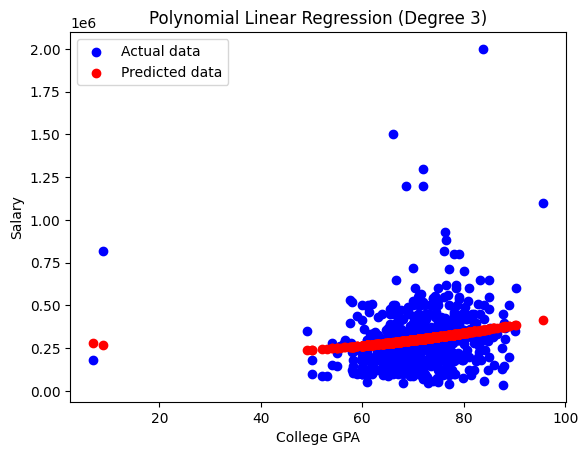

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual data')
plt.scatter(X_test, y_pred, color='red', label='Predicted data')
plt.xlabel('College GPA')
plt.ylabel('Salary')
plt.title(f'Polynomial Linear Regression (Degree {degree})')
plt.legend()
plt.show()

## The given results are evaluation metrics for different regression models applied to a dataset. Here's a brief interpretation:

### Simple Linear Regression:
##### Mean Squared Error (MSE): 178711.97
##### R^2 (Coefficient of Determination): 0.0328
##### Mean Absolute Error (MAE): 118475.35


### Multiple Linear Regression:
##### Mean Squared Error (MSE): 162972.19
##### R^2 (Coefficient of Determination): 0.1957
##### Mean Absolute Error (MAE): 106213.16

### Polynomial Regression (Degree 2):
##### Mean Squared Error (MSE): 177368.93
##### R^2 (Coefficient of Determination): 0.0473
##### Mean Absolute Error (MAE): 118245.68

### Polynomial Regression (Degree 3):
##### Mean Squared Error (MSE): 177314.97
##### R^2 (Coefficient of Determination): 0.0479
##### Mean Absolute Error (MAE): 118152.87